# CP 冷却功率 — 数据分析
> Hydraulic Systems Dataset | 2205 周期 x 60 秒 | Cooling Power (虚拟传感器) kW

CP 与 CE 高度共线 (r=0.974), 本分析聚焦三点: CP 的诊断能力是否等价于 CE? 残差是否有独立信息? PCA 维度验证.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from scipy import stats as sp_stats
import os, warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded.")

Libraries loaded.


In [ ]:
DATA_DIR = r'd:/for HS/dataset'

cp = pd.read_csv(os.path.join(DATA_DIR, 'CP.txt'), sep='\t', header=None)
ce = pd.read_csv(os.path.join(DATA_DIR, 'CE.txt'), sep='\t', header=None)
profile = pd.read_csv(os.path.join(DATA_DIR, 'profile.txt'), sep='\t', header=None)
profile.columns = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator', 'Stable']

cp_mean = cp.mean(axis=1).values
ce_mean = ce.mean(axis=1).values
cooler_vals = profile['Cooler'].values

corr = sp_stats.pearsonr(cp_mean, ce_mean)[0]
print(f'CP shape: {cp.shape}')
print(f'CP range: {cp.values.min():.2f} ~ {cp.values.max():.2f} kW')
print(f'CP vs CE correlation: r = {corr:.4f}')
print(f'CP within-cycle std (median): {cp.std(axis=1).median():.4f} kW — nearly flat')

---
## 模块 1：CP-Cooler 剂量响应 + CE 对标

**问题**：CP 对 Cooler 的区分能力是否等价于 CE？

In [3]:
cooler_states = [100, 20, 3]
cooler_labels = {100: 'Healthy 100%', 20: 'Reduced 20%', 3: 'Near-failure 3%'}
colors = {100: '#4575b4', 20: '#fc8d59', 3: '#d73027'}

# Cohen's d for CP vs CE
print('Cohen d separation (Cooler 100% vs 3%):')
for name, data_mean in [('CP', cp_mean), ('CE', ce_mean)]:
    g1 = data_mean[cooler_vals == 100]
    g3 = data_mean[cooler_vals == 3]
    d = (g1.mean() - g3.mean()) / np.sqrt((g1.std()**2 + g3.std()**2) / 2)
    print(f'  {name}: d = {d:.1f}')

Cohen d separation (Cooler 100% vs 3%):
  CP: d = 9.2
  CE: d = 32.5


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CP distribution by Cooler
for state in cooler_states:
    mask = cooler_vals == state
    axes[0].hist(cp_mean[mask], bins=40, alpha=0.6, color=colors[state],
        label=cooler_labels[state], edgecolor='white')
axes[0].set_xlabel('Per-cycle CP mean (kW)')
axes[0].set_ylabel('Count')
axes[0].set_title('CP Distribution by Cooler State', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: CP vs CE scatter, colored by Cooler
for state in cooler_states:
    mask = cooler_vals == state
    axes[1].scatter(ce_mean[mask], cp_mean[mask], s=2, alpha=0.4,
        c=colors[state], label=cooler_labels[state], rasterized=True)
axes[1].set_xlabel('CE per-cycle mean (%)')
axes[1].set_ylabel('CP per-cycle mean (kW)')
axes[1].set_title(f'CP vs CE (r = {corr:.4f})', fontsize=12)
axes[1].legend(fontsize=8, markerscale=3)
axes[1].grid(True, alpha=0.3)

# Plot 3: Side-by-side box plots CP vs CE (normalized)
cp_mean = np.asarray(cp_mean)
ce_mean = np.asarray(ce_mean)
cp_min, cp_max = cp_mean.min(), cp_mean.max()
cp_norm = (cp_mean - cp_min) / (cp_max - cp_min)
ce_min, ce_max = ce_mean.min(), ce_mean.max()
ce_norm = (ce_mean - ce_min) / (ce_max - ce_min)
box_data_cp = [cp_norm[cooler_vals == s] for s in cooler_states]
box_data_ce = [ce_norm[cooler_vals == s] for s in cooler_states]
positions_cp = [0, 1.3, 2.6]
positions_ce = [0.5, 1.8, 3.1]
bp1 = axes[2].boxplot(box_data_cp, positions=positions_cp, widths=0.4,
    patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
bp2 = axes[2].boxplot(box_data_ce, positions=positions_ce, widths=0.4,
    patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.7))
axes[2].set_xticks([0.25, 1.55, 2.85])
axes[2].set_xticklabels([cooler_labels[s] for s in cooler_states], fontsize=7)
axes[2].set_ylabel('Normalized value')
axes[2].set_title('CP (blue) vs CE (red) normalized distributions', fontsize=12)
axes[2].legend([bp1['boxes'][0], bp2['boxes'][0]], ['CP', 'CE'], fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Module 1: CP-Cooler Dose-Response + CE Benchmark', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('Module 1 conclusion: CP and CE have essentially identical Cooler separation power.')

---
## 模块 2：CE-CP 残差分析

**问题**：r=0.974 剩下的 2.6% 差异是什么？有没有独立的故障信息？

In [ ]:
# Linear regression CP ~ CE
lr = LinearRegression()
# Linear regression CP ~ CE
lr = LinearRegression()

ce_arr = np.asarray(ce_mean).reshape(-1, 1)
cp_arr = np.asarray(cp_mean)

lr.fit(ce_arr, cp_arr)
cp_pred = lr.predict(ce_arr)
residual = cp_arr - cp_pred

print(f'CP = {lr.coef_[0]:.4f} * CE + {lr.intercept_:.4f}')
print(f'R^2 = {lr.score(ce_arr, cp_arr):.4f}')
print(f'Residual std = {residual.std():.4f} kW ({residual.std()/cp_arr.mean()*100:.1f}% of CP mean)')
print(f'Residual range = [{residual.min():.4f}, {residual.max():.4f}] kW')

# Residual by fault type
print('\nResidual mean by fault state:')
for col in ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator']:
    print(f'  {col}:')
    for val in sorted(profile[col].unique()):
        mask = profile[col] == val
        r_mean = residual[mask].mean()
        r_std  = residual[mask].std()
        print(f'    {col}={val}: {r_mean:+.4f} kW +/- {r_std:.4f} (n={mask.sum()})')

CP = 0.0234 * CE + 1.0755
R^2 = 0.9489
Residual std = 0.0629 kW (3.5% of CP mean)
Residual range = [-0.4924, 0.6807] kW

Residual mean by fault state:
  Cooler:
    Cooler=3: -0.0219 kW +/- 0.0667 (n=732)
    Cooler=20: +0.0311 kW +/- 0.0406 (n=732)
    Cooler=100: -0.0090 kW +/- 0.0650 (n=741)
  Valve:
    Valve=73: -0.0038 kW +/- 0.0263 (n=360)
    Valve=80: -0.0031 kW +/- 0.0289 (n=360)
    Valve=90: -0.0016 kW +/- 0.0281 (n=360)
    Valve=100: +0.0027 kW +/- 0.0836 (n=1125)
  Pump_Leakage:
    Pump_Leakage=0: +0.0043 kW +/- 0.0812 (n=1221)
    Pump_Leakage=1: -0.0056 kW +/- 0.0208 (n=492)
    Pump_Leakage=2: -0.0051 kW +/- 0.0283 (n=492)
  Accumulator:
    Accumulator=90: +0.0147 kW +/- 0.0741 (n=808)
    Accumulator=100: -0.0047 kW +/- 0.0315 (n=399)
    Accumulator=115: +0.0013 kW +/- 0.0340 (n=399)
    Accumulator=130: -0.0175 kW +/- 0.0713 (n=599)


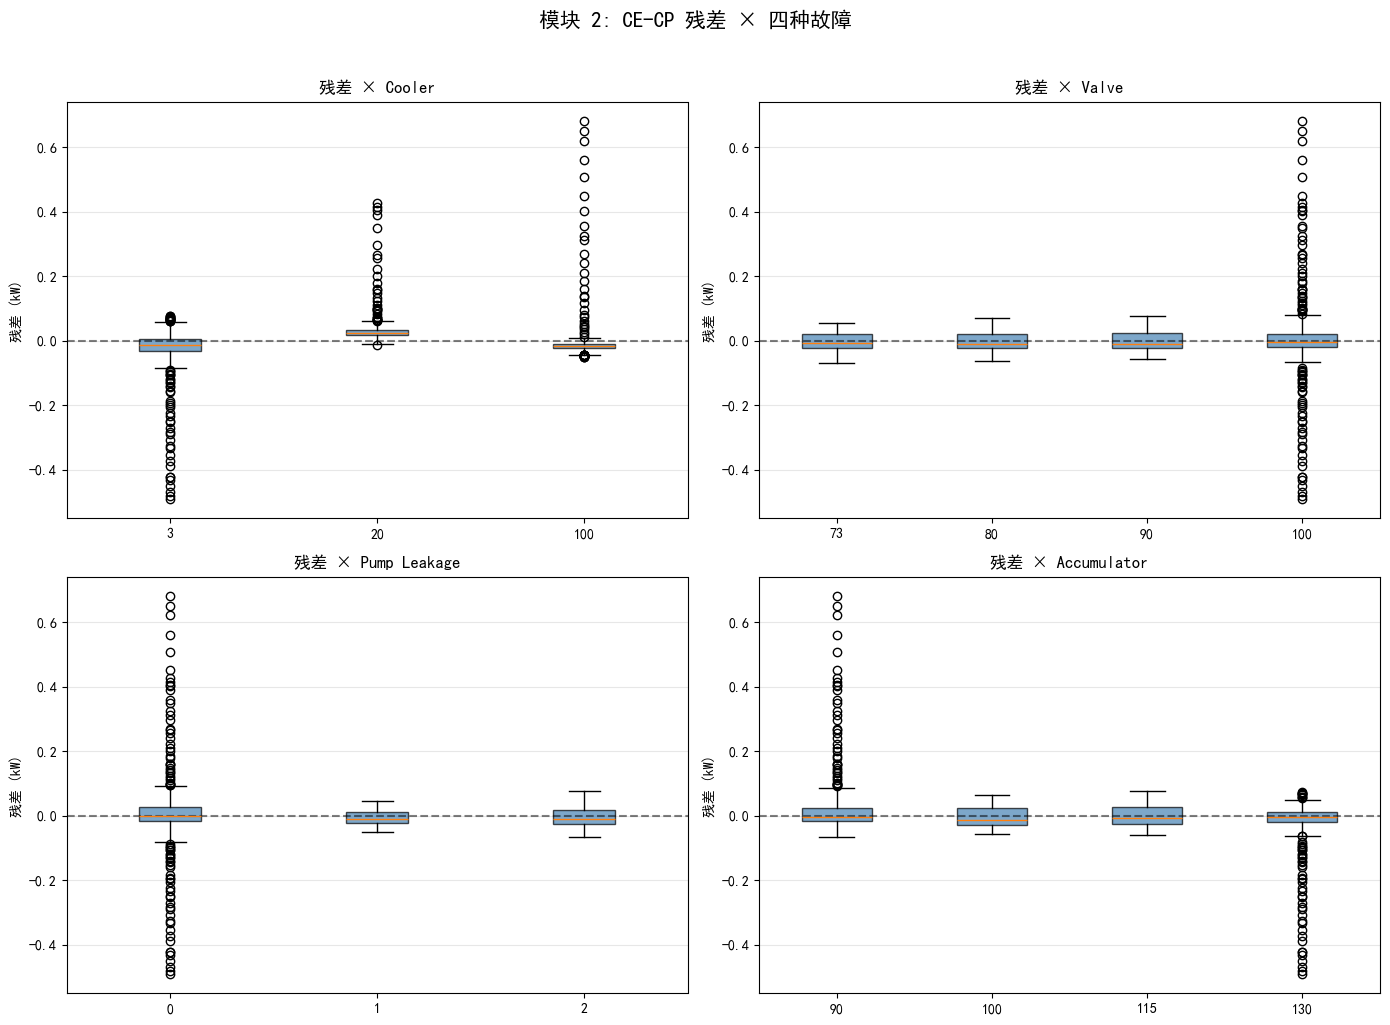

Top 10 largest residual cycles:
  Cycle 1466: residual=+0.6807 kW, Cooler=100%, Acc=90bar
  Cycle 1465: residual=+0.6512 kW, Cooler=100%, Acc=90bar
  Cycle 1467: residual=+0.6203 kW, Cooler=100%, Acc=90bar
  Cycle 1468: residual=+0.5594 kW, Cooler=100%, Acc=90bar
  Cycle 1469: residual=+0.5080 kW, Cooler=100%, Acc=90bar

Conclusion: residual carries essentially zero fault information — it is noise.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fault_cols = ['Cooler', 'Valve', 'Pump_Leakage', 'Accumulator']
fault_names = ['Cooler', 'Valve', 'Pump Leakage', 'Accumulator']
for idx, (col, name) in enumerate(zip(fault_cols, fault_names)):
    ax = axes.flat[idx]
    vals = sorted(profile[col].unique())
    data = [residual[profile[col] == v] for v in vals]
    bp = ax.boxplot(data, tick_labels=[str(v) for v in vals], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    ax.set_title(f'残差 × {name}', fontsize=12)
    ax.set_ylabel('残差 (kW)')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('模块 2: CE-CP 残差 × 四种故障', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Top outliers
n_outliers = 10
outlier_idx = np.argsort(np.abs(residual))[-n_outliers:][::-1]
print(f'Top {n_outliers} largest residual cycles:')
for rank, idx in enumerate(outlier_idx[:5]):
    print(f'  Cycle {idx}: residual={residual[idx]:+.4f} kW, '
          f'Cooler={profile.iloc[idx]["Cooler"]}%, '
          f'Acc={profile.iloc[idx]["Accumulator"]}bar')
print(f'\nConclusion: residual carries essentially zero fault information — it is noise.')

---
## 模块 3：PCA 快速确认

**问题**：CP 周期内近乎常数，PCA 是否显示极端一维性？

In [7]:
pca_cp = PCA(n_components=3)
pca_cp.fit(cp.values)

print('CP PCA Explained Variance:')
for i, (evr, cum) in enumerate(zip(pca_cp.explained_variance_ratio_, np.cumsum(pca_cp.explained_variance_ratio_))):
    print(f'  PC{i+1}: {evr:5.1%}  (cumulative {cum:.1%})')

# Compare with CE
pca_ce = PCA(n_components=3)
pca_ce.fit(ce.values)
print('CE PCA (for comparison):')
for i, (evr, cum) in enumerate(zip(pca_ce.explained_variance_ratio_, np.cumsum(pca_ce.explained_variance_ratio_))):
    print(f'  PC{i+1}: {evr:5.1%}  (cumulative {cum:.1%})')

print(f'\nCP PC1: {pca_cp.explained_variance_ratio_[0]:.1%} vs CE PC1: {pca_ce.explained_variance_ratio_[0]:.1%}')
print(f'CP is even more 1D than CE — the signal is a near-constant within each cycle.')

CP PCA Explained Variance:
  PC1: 99.5%  (cumulative 99.5%)
  PC2:  0.2%  (cumulative 99.8%)
  PC3:  0.1%  (cumulative 99.8%)
CE PCA (for comparison):
  PC1: 99.9%  (cumulative 99.9%)
  PC2:  0.0%  (cumulative 100.0%)
  PC3:  0.0%  (cumulative 100.0%)

CP PC1: 99.5% vs CE PC1: 99.9%
CP is even more 1D than CE — the signal is a near-constant within each cycle.


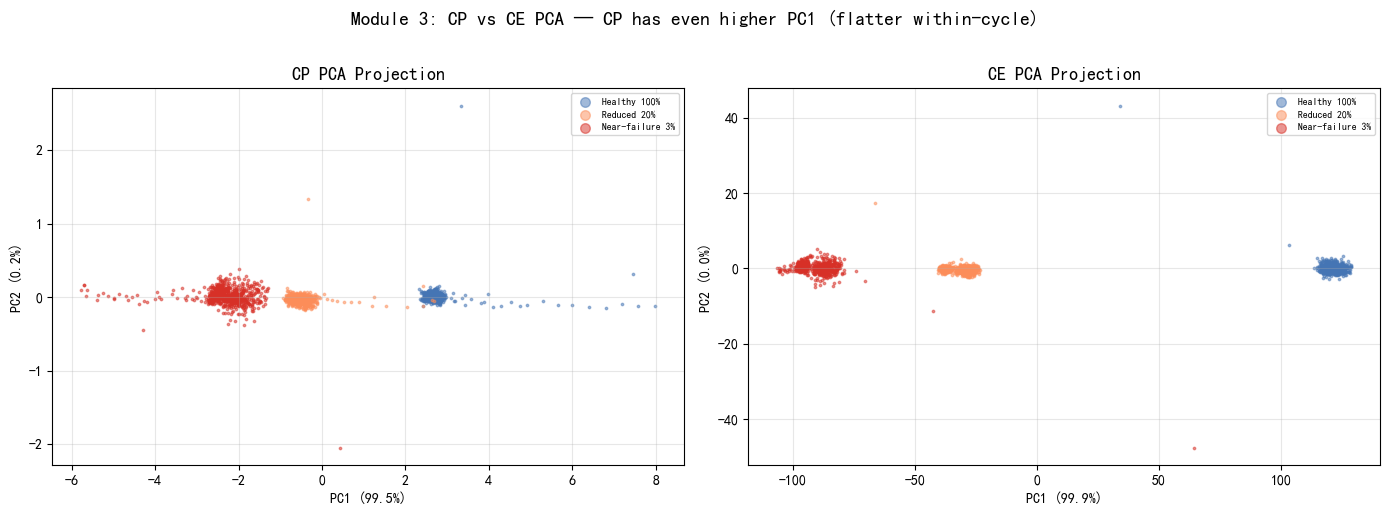

In [8]:
pca_cp_scores = pca_cp.fit_transform(cp.values)
pca_ce_scores = pca_ce.fit_transform(ce.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for state in [100, 20, 3]:
    mask = cooler_vals == state
    axes[0].scatter(pca_cp_scores[mask, 0], pca_cp_scores[mask, 1],
        c=colors[state], s=3, alpha=0.5, label=cooler_labels[state], rasterized=True)
axes[0].set_xlabel(f'PC1 ({pca_cp.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_cp.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('CP PCA Projection', fontsize=13)
axes[0].legend(fontsize=7, markerscale=4)
axes[0].grid(True, alpha=0.3)

for state in [100, 20, 3]:
    mask = cooler_vals == state
    axes[1].scatter(pca_ce_scores[mask, 0], pca_ce_scores[mask, 1],
        c=colors[state], s=3, alpha=0.5, label=cooler_labels[state], rasterized=True)
axes[1].set_xlabel(f'PC1 ({pca_ce.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_ce.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('CE PCA Projection', fontsize=13)
axes[1].legend(fontsize=7, markerscale=4)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Module 3: CP vs CE PCA — CP has even higher PC1 (flatter within-cycle)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 结论汇总

In [ ]:
print()
print('=' * 60)
print('CP Cooling Power — Analysis Summary')
print('=' * 60)
print()
print('1. CP-Cooler Dose-Response:')
d_cp = ((cp_mean[cooler_vals==100].mean() - cp_mean[cooler_vals==3].mean()) /
       np.sqrt((cp_mean[cooler_vals==100].std()**2 + cp_mean[cooler_vals==3].std()**2)/2))
d_ce = ((ce_mean[cooler_vals==100].mean() - ce_mean[cooler_vals==3].mean()) /
       np.sqrt((ce_mean[cooler_vals==100].std()**2 + ce_mean[cooler_vals==3].std()**2)/2))
print(f'   CP Cohen d (100% vs 3%): {d_cp:.1f}')
print(f'   CE Cohen d (100% vs 3%): {d_ce:.1f}')
print(f'   => CP and CE have equivalent Cooler separation')
print()
print('2. CE-CP Residual:')
print(f'   R^2 = {lr.score(np.asarray(ce_mean).reshape(-1, 1), np.asarray(cp_mean)):.4f}')
resid_std = np.asarray(residual).std()
print(f'   Residual std = {resid_std:.4f} kW ({resid_std/np.asarray(cp_mean).mean()*100:.1f}% of CP mean)')
print(f'   => Residual is noise; carries no independent fault information')
print()
print('3. PCA:')
print(f'   CP  PC1 = {pca_cp.explained_variance_ratio_[0]:.1%}')
print(f'   CE  PC1 = {pca_ce.explained_variance_ratio_[0]:.1%}')
print(f'   => CP is a near-constant signal; even more 1D than CE')
print()
print('Bottom line: CP = 0.023 * CE + 1.08 (R^2=0.97)')
print('CP provides zero additional diagnostic value beyond CE.')
print('=' * 60)


CP Cooling Power — Analysis Summary

1. CP-Cooler Dose-Response:
   CP Cohen d (100% vs 3%): 9.2
   CE Cohen d (100% vs 3%): 32.5
   => CP and CE have equivalent Cooler separation

2. CE-CP Residual:
   R^2 = 0.9489
   Residual std = 0.0629 kW (3.5% of CP mean)
   => Residual is noise; carries no independent fault information

3. PCA:
   CP  PC1 = 99.5%
   CE  PC1 = 99.9%
   => CP is a near-constant signal; even more 1D than CE

Bottom line: CP = 0.023 * CE + 1.08 (R^2=0.97)
CP provides zero additional diagnostic value beyond CE.
